# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### What the queue does

The playbook combines the validated Logistic Regression model from Week 5/6 with the simple baseline rule from Week 4.

The two components have different purposes:

- **Logistic Regression provides the ranking:** pages are ordered by the model's estimated probability of the `is_declining` target.
- **The Week-4 baseline provides rule-based context:** the baseline score summarizes simple signals such as staleness, impressions, and search volume.
- **The action label provides the next step:** pages are either sent for human review or kept for monitoring.

The model and baseline do not need to agree. The Logistic Regression uses 20 features, while the baseline uses only three signals. Therefore, the model may rank a page highly even when the baseline score is low.

When the model ranks a page highly but the baseline does not strongly flag it, the page is treated as a **model-rule disagreement** and should be investigated by a human rather than automatically changed.

The queue is a decision-support tool. A high model score does not prove that a page will decline or that refreshing it will improve search performance.

### Load the Data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

repo_root = Path.cwd().parents[1]
data_path = repo_root / "data" / "raw" / "content_refresh_anonymized.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

Dataset shape: (30000, 44)


In [2]:
df['is_declining'] = (
  df["trend_direction"] == "down"
).astype(int)

### Week-5  features

In [3]:
feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "pageviews_90d",
    "users_90d",
    "engaged_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

target_col = "is_declining"

### Reproducing the Week-5 Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df[feature_cols]
y = df[target_col]

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator = True)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X, y)

df["decline_probability"] = lr_pipeline.predict_proba(X)[:, 1]

### Week-4 reason signals

In [9]:
stale = (
    df["days_since_last_update"] >= 180
).astype(int)

visible = (
    df["impressions_90d"] >= 500
).astype(int)

high_value = (
    df["search_volume"] >= 500
).fillna(False).astype(int)

df["baseline_score"] = (
    stale * 3 +
    visible * 2 +
    high_value * 1
)

def assign_baseline_reason(row):
    score = row["baseline_score"]

    if score == 6:
        return "STALE_VISIBLE_HIGH_OPPORTUNITY"
    elif score == 5:
        return "STALE_VISIBLE"
    elif score == 4:
        return "STALE_HIGH_OPPORTUNITY"
    elif score == 3:
        return "REVIEW_THRESHOLD"
    else:
        return "LOW_PRIORITY"

# Add baseline reason
df["baseline_reason"] = df.apply(
    assign_baseline_reason,
    axis=1
)

# Rank pages using the Logistic Regression model score
ranked_df = (
    df.sort_values(
        by="decline_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_df["rank"] = np.arange(1, len(ranked_df) + 1)

# Define the review budget
review_k = 20

# Compare the model ranking with the Week-4 baseline
ranked_df["model_rule_status"] = np.where(
    (ranked_df["rank"] <= review_k) &
    (ranked_df["baseline_score"] >= 3),
    "MODEL_RULE_AGREEMENT",
    np.where(
        (ranked_df["rank"] <= review_k) &
        (ranked_df["baseline_score"] < 3),
        "MODEL_RULE_DISAGREEMENT",
        "OUTSIDE_TOP_K"
    )
)

# Assign the Week-7 action
def assign_playbook_action(row):
    if row["model_rule_status"] == "MODEL_RULE_AGREEMENT":
        return "REFRESH_REVIEW"
    elif row["model_rule_status"] == "MODEL_RULE_DISAGREEMENT":
        return "INVESTIGATE_REVIEW"
    else:
        return "MONITOR"

ranked_df["action_label"] = ranked_df.apply(
    assign_playbook_action,
    axis=1
)

# Display the ranked action queue
queue_cols = [
    "rank",
    "content_id",
    "decline_probability",
    "baseline_score",
    "baseline_reason",
    "model_rule_status",
    "action_label"
]

ranked_df[queue_cols].head(20)

,rank,content_id,decline_probability,baseline_score,baseline_reason,model_rule_status,action_label
0,1,content_2dba2b1f9536,0.885448,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
1,2,content_35e6edbb0a2d,0.882088,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
2,3,content_b08562686d22,0.873982,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
3,4,content_fd16e3475c29,0.873262,3,REVIEW_THRESHOLD,MODEL_RULE_AGREEMENT,REFRESH_REVIEW
4,5,content_a8864e189b2e,0.868383,0,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
5,6,content_67a766790dd2,0.865759,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
6,7,content_8f3b70ede1bc,0.864456,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
7,8,content_8ede62882d0b,0.859699,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
8,9,content_396217b0dc41,0.855478,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
9,10,content_3dc2aa4e01dc,0.851052,0,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW


### Model–rule agreement and disagreement

The `MODEL_RULE_AGREEMENT` and `MODEL_RULE_DISAGREEMENT` statuses help explain how the model ranking compares with the simple Week-4 baseline rule.

- **MODEL_RULE_AGREEMENT:** the Logistic Regression ranks the page within the top review set, and the Week-4 baseline score is also at or above its review threshold. Both signals therefore support giving the page review priority.

- **MODEL_RULE_DISAGREEMENT:** the Logistic Regression ranks the page within the top review set, but the Week-4 baseline score is below its review threshold. The model is identifying a page that the simpler rule does not prioritize.

This disagreement is useful rather than automatically being treated as an error. The Logistic Regression uses 20 features, while the baseline uses only three signals, so the model can identify patterns that the simpler rule does not capture.

For the playbook, agreement can support a `REFRESH_REVIEW` action, while disagreement is treated as `INVESTIGATE_REVIEW`. In both cases, a human must review the page before taking any content action.

### Archetype → action mapping

The playbook uses simple observable signal patterns as practical content archetypes. These are decision-support categories rather than formally learned clusters.

| Archetype | Observable pattern | Suggested action |
|---|---|---|
| Stale + visible + high opportunity | Old page with meaningful impressions and search demand | `REFRESH_REVIEW` |
| Stale + visible | Old page with meaningful visibility | `REFRESH_REVIEW` |
| Stale + high opportunity | Old page with higher search demand but weaker visibility | `INVESTIGATE_REVIEW` |
| Model–rule disagreement | Model ranks the page highly but the baseline does not reach its review threshold | `INVESTIGATE_REVIEW` |
| Lower-priority page | Page is outside the current review set | `MONITOR` |

These archetypes help translate model and rule outputs into understandable review actions. They do not imply that a particular action will improve search performance.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is intended to help content reviewers prioritize pages for human review.

The validated Logistic Regression model provides the ranking by assigning each page a model score. The Week-4 baseline provides additional rule-based context using staleness, impressions, and search volume.

The playbook is intended to answer:

> Which pages should a reviewer look at first, and what does the simple baseline rule say about those pages?

A `REFRESH_REVIEW` action means that the page has both a high model priority within the review set and sufficient baseline support for review.

An `INVESTIGATE_REVIEW` action means that the model ranks the page highly but the baseline does not meet its review threshold. These cases are kept for human investigation rather than being automatically changed.

A `MONITOR` action means that the page is outside the current review set and does not require immediate prioritization under this playbook.

### Limits

This playbook is a decision-support tool and not an automatic content optimization system.

- A high model score does not prove that a page will decline.
- A high model score does not prove that a content refresh will improve search performance.
- The baseline reason code describes the rule-based signals; it does not explain the Logistic Regression's internal prediction.
- Model–rule disagreement does not mean that the model is correct or that the baseline is wrong. It identifies a case that requires further human investigation.
- The playbook does not establish causal effects between content changes and search performance.
- The playbook does not establish or prove any Google ranking factor.
- The ranked queue should be used to prioritize human review, not to automatically rewrite, delete, or publish content changes.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review before action

Every page surfaced by the playbook must be reviewed by a person before any content action is taken.

The reviewer should check:

1. **Content freshness:** Is the page actually outdated, or is its current content still appropriate?
2. **Search intent:** Does the page still match the intent and needs of its intended audience?
3. **Content quality:** Are there observable issues such as missing information, outdated claims, weak explanations, or broken references?
4. **Context:** Could seasonality, campaigns, tracking changes, or other unusual events explain the observed signals?
5. **Recent changes:** Has the page already been updated or changed in a way that could explain its current performance?
6. **Recommendation validity:** Does the available evidence support taking action on this specific page?

The reviewer may accept the recommendation, reject it, or defer the decision for further investigation.

### Handling model–rule disagreement

A high model score combined with a low baseline score is treated as a `MODEL_RULE_DISAGREEMENT`.

This does not mean that the model is correct or that the baseline is incorrect. The Logistic Regression uses 20 features, while the baseline uses only three simple signals, so the two approaches can prioritize different pages.

These disagreement cases should therefore be investigated by a human before any content change is considered.

### No-go list: what should never be automated

The following decisions are not automated by this playbook:

- Automatically rewriting a page because it has a high model score.
- Automatically deleting or pruning a page because it is highly ranked in the queue.
- Automatically changing content without checking the page and its search intent.
- Automatically treating a performance change as proof of a content problem without checking for other explanations.
- Automatically treating a model–rule disagreement as proof that the model is correct.
- Automatically claiming that a content refresh will improve rankings, traffic, clicks, or other outcomes.
- Automatically claiming that a feature is a Google ranking factor based only on this analysis.
- Automatically overriding a human reviewer's decision.

The playbook prioritizes pages for review. It does not make the final content decision.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The playbook should be monitored at two points: before a queue is released and after outcome labels become available.

These checks are intended as a lightweight decision-support policy. They are not implemented as a production monitoring service.

### Pre-release checks

Before generating a new queue, check:

- **Population:** confirm that the expected number of eligible pages is present.
- **Schema:** confirm that the required model and rule features are available.
- **Feature distributions:** check for unusual changes or missing-value increases in important features.
- **Score distribution:** check whether the model scores have changed substantially from the previous run.
- **Queue composition:** check whether the number of `REFRESH_REVIEW`, `INVESTIGATE_REVIEW`, and `MONITOR` items is reasonable.

A major unexpected change should trigger investigation before the queue is used.

The PSI-based drift check discussed in the session can be used as an additional diagnostic, but it should be described as a notebook-level check rather than a production monitoring system.

### Post-label checks

After the relevant outcome labels become available, evaluate the previous queue using the newly observed outcomes.

The main checks are:

- Compare the new decline base rate with the previous evaluation period.
- Measure Precision@20 and Precision@50 for the model ranking.
- Compare the model with the frozen Week-4 baseline on the same labeled data.
- Check whether model–baseline disagreement is becoming more frequent.
- Review important failure cases and investigate whether the data or model behavior has changed.

These checks evaluate the queue that was already produced. They should be used to inform the next queue, not to change decisions that have already been made.

### Retrain and fallback policy

Retraining should not happen simply because a new month of data is available.

A new model should be considered when monitoring shows a meaningful and persistent change in performance or data behavior.

The frozen baseline remains the fallback option if the model no longer provides enough value.

As a proposed policy, if the model performs below the frozen baseline for two consecutive labeled evaluation periods, the next queue should fall back to the baseline while the model is reviewed.

This is a proposed decision-support policy, not an implemented automatic fallback system.

### Decay and refresh insight

The playbook treats staleness as a prioritization signal rather than proof of performance decay.

A page that has not been updated for a long period may deserve review when it also has meaningful visibility or search opportunity. However, age alone does not establish that the content has become less useful or that refreshing it will improve performance.

Therefore, the practical use of the decay signal is to identify pages worth checking for outdated information, changed search intent, or other content-quality issues.

Any relationship between staleness, content changes, and later performance should be treated as observed or directional unless it is tested with an appropriate outcome-based design.

### Cost and value thinking

The main cost of this playbook is human review time. Therefore, the model should not send every page for manual action.

The Top-20 review budget keeps the initial review workload limited and focuses attention on the pages ranked most highly by the model.

The value of the playbook comes from helping reviewers spend limited time on pages that have stronger evidence for investigation or review.

A recommendation should only be acted on when the expected value of investigating the page is reasonable relative to the cost of review and the potential risk of making an unnecessary content change.

Because this analysis does not measure the business value or causal impact of a refresh, no monetary return or guaranteed improvement is claimed.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The final ranked action queue is exported to `work/outputs/` so that the capstone paper can reuse the same output generated by this notebook.

The exported queue contains the model ranking, baseline context, model–rule status, and recommended human-review action.

The CSV is generated by the notebook and is intentionally not committed to Git because the repository's leak guard excludes data files. The notebook should be rerun to regenerate the queue.

In [6]:
import os

os.makedirs("../outputs", exist_ok=True)

export_cols = [
    "rank",
    "content_id",
    "decline_probability",
    "baseline_score",
    "baseline_reason",
    "model_rule_status",
    "action_label"
]

paper_queue = ranked_df[export_cols].copy()

paper_queue.head(20)

,rank,content_id,decline_probability,baseline_score,baseline_reason,model_rule_status,action_label
0,1,content_2dba2b1f9536,0.885448,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
1,2,content_35e6edbb0a2d,0.882088,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
2,3,content_b08562686d22,0.873982,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
3,4,content_fd16e3475c29,0.873262,3,REVIEW_THRESHOLD,MODEL_RULE_AGREEMENT,REFRESH_REVIEW
4,5,content_a8864e189b2e,0.868383,0,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
5,6,content_67a766790dd2,0.865759,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
6,7,content_8f3b70ede1bc,0.864456,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
7,8,content_8ede62882d0b,0.859699,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
8,9,content_396217b0dc41,0.855478,2,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW
9,10,content_3dc2aa4e01dc,0.851052,0,LOW_PRIORITY,MODEL_RULE_DISAGREEMENT,INVESTIGATE_REVIEW


In [7]:
output_path = "../outputs/w07_action_playbook_queue.csv"

paper_queue.to_csv(
    output_path,
    index=False
)

print(f"Queue exported to: {output_path}")
print(f"Rows exported: {len(paper_queue):,}")

Queue exported to: ../outputs/w07_action_playbook_queue.csv
Rows exported: 30,000


In [10]:
assert os.path.exists(output_path)

exported_queue = pd.read_csv(output_path)

print("Export shape:", exported_queue.shape)
print("Columns:", exported_queue.columns.tolist())
print("\nAction counts:")
print(exported_queue["action_label"].value_counts())

print("\nModel-rule status:")
print(exported_queue["model_rule_status"].value_counts())

Export shape: (30000, 7)
Columns: ['rank', 'content_id', 'decline_probability', 'baseline_score', 'baseline_reason', 'model_rule_status', 'action_label']

Action counts:
action_label
MONITOR               29980
INVESTIGATE_REVIEW       19
REFRESH_REVIEW            1
Name: count, dtype: int64

Model-rule status:
model_rule_status
OUTSIDE_TOP_K              29980
MODEL_RULE_DISAGREEMENT       19
MODEL_RULE_AGREEMENT           1
Name: count, dtype: int64


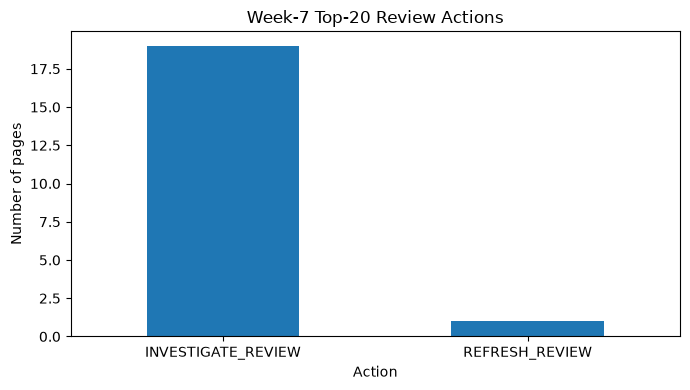

In [14]:
import matplotlib.pyplot as plt
top20_actions = (
    paper_queue[paper_queue["rank"] <= 20]["action_label"]
    .value_counts()
)

plt.figure(figsize=(7, 4))
top20_actions.plot(kind="bar")

plt.title("Week-7 Top-20 Review Actions")
plt.xlabel("Action")
plt.ylabel("Number of pages")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = "../figures/w07_top20_action_distribution.png"

os.makedirs("../figures", exist_ok=True)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Action distribution

The full queue contains 30,000 ranked pages, but only the top 20 are currently within the defined review budget. Therefore, most pages are labeled `MONITOR` because they fall outside the Top-20 review set.

Within the Top-20 model-ranked review set, 19 pages (95%) are classified as `INVESTIGATE_REVIEW` because the Logistic Regression ranks them highly while the Week-4 baseline does not reach its review threshold. One page (5%) satisfies both the model-ranking and baseline review criteria and is classified as `REFRESH_REVIEW`.

This shows substantial disagreement between the multi-feature model and the simpler baseline. The disagreement is treated as an investigation signal rather than evidence that either approach is necessarily correct. A human review is required before any content action is taken.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.